# 1 Preparation instruction


Users can run most of the cells in this notebook to obtain desired visualized outputs, except for the Sankey Diagram in section 4.3.3, where visualisation can only be stored as an html file. Meanwhile, before running this notebook on a local machine, users should first install 7 modules from the command line. These include:
<li>pip install geopandas
<li>pip install country_converter
<li>pip install squarify
<li>pip install pyecharts
<li>pip install networkx
<li>pip install plotly==5.5.0
<li>pip install decorator==5.0.9
    
Moreover, for section 3.1 to 3.5, since it may take hours to reproduce the dataset using the API, and the API of the selected website is not always stable enough, the relevant data are saved in several excel files. Users can directly reload them instead of executing the original data acquisition code to reproduce the interactive plots.


In [1]:
# Setting up Packages
import json
import country_converter as coco
from datetime import datetime, timedelta
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import squarify
import requests
import os
import re
from adjustText import adjust_text
from bs4 import BeautifulSoup
import time
import xlwt
import xlrd
import networkx as nx
import math
from pyecharts.charts import Sankey
from pyecharts import options as opts
import plotly.express as px
import seaborn

ModuleNotFoundError: No module named 'adjustText'

# 2 Introduction

## Why we choose this topic?

Global trade has endured a significant disruption under the long-term covid impact. Countries launched various covid restriction over international travel and trades, which results in signicifant transportation limitation, vulnerabilities in supply chain and countries' industrial structure and rising economic nationalism. This all contributes a permanent restructing of trading network around the world and a trading network more adapatble to the new normal.
This inspires us to take a close look at the global trade under the new normal upon our major database of UN Comtrade. 

## Research Questions and Analysis Structure:

Considering the global trade under the new normal, we want to focus on the following question:
* What are the most active game players in terms of the volume and fastest-growing players in the global trading network?
* What does these countries and regions' balance of trade(BOT) account looks like? Are they facing with trade deficit or trade surplus?
* How is the trading network and mutual trading volume (correlation) between G-20 countries?
* What is China's role in the global trading network from 1993 to 2021? Who are our largest trading partners?
* What is the specific structure of exports products of China?
* Does China's trading pattern fit in the gravity mpdel of international trade?

We take two steps to dive in our analysis. 
<br>1)  For the first part, we look at the global trading network, including the total imports and exports volume of each country or region, the respective growth rates of imports and exports from 2019 to 2020 and the trade correlation among G-20 countries. 
<br>2)  For the second part, we zoom in China's role in international trade. We analyze China's trading pattern from three perspective of volume, respectively the net volume, the exports categories and the trading network.

## Data Source Description:

* Core Data: UN Comtrade
We use UN Comtrade as our major database. UN Comtrade refers to 'United Nations International Trade Statistics Database', which is the largest database for international trade. It provides trade data for over 170 countries and regions, detailed by different products/service categories and the mutual exports/imports volume.  
* Supplementary Data: 
GDP and geographical location(Longitude and latitude) data are used in parts of our analysis. We use the web-scraping to gather data we need and the website links are as follows:
<br>1) http://techslides.com/list-of-countries-and-capitals#google_vignette ;
<br>2) https://tradingeconomics.com/country-list/gdp

# 3 Data Acquisition
In this section, we aim to obtain all the data we need to prepare for the visulization and analysis. The main method of getting data is to use API provided by UN Comtrade. However, we also encounter a small problem in the process of obtaining data, which is the instability of the API. We can get the majority of data with the help of API, but sometimes a small part of data cannot be accessed via the API. In response to this problem, we fill the missing value manually in Excel and get eventually an Excel file which includes complete data.

## 3.1 Trade Volume for 131 Countries and regions in 2020
In this subsection, we first extract the M49 codes for all 249 countries and regions listed on the website of UN statistics divison. However, the trade volume for some are not available on the UN ComTrade. Therefore, we manually filter 131 countries and regions that play relatively active part in international trade and obtain the trade volume of them in 2020 instead.

In [2]:
# extract the M49 codes of 249 countries and regions
res_con = requests.get("https://unstats.un.org/unsd/methodology/m49/")
soup = BeautifulSoup(res_con.content,'lxml')
lists = soup.find_all('tr')[0:250]
char = []
ind = []
for tr in lists:
    chars = tr.text.split('/n')
    element = chars[0].split('\n')
    char.append(element[1])
    ind.append(element[2])
country_code = [int(i) for i in ind[1:len(ind)-1]]
country_code[-11]=842
print(country_code)

[4, 248, 8, 12, 16, 20, 24, 660, 10, 28, 32, 51, 533, 36, 40, 31, 44, 48, 50, 52, 112, 56, 84, 204, 60, 64, 68, 535, 70, 72, 74, 76, 86, 92, 96, 100, 854, 108, 132, 116, 120, 124, 136, 140, 148, 152, 156, 344, 446, 162, 166, 170, 174, 178, 184, 188, 384, 191, 192, 531, 196, 203, 408, 180, 208, 262, 212, 214, 218, 818, 222, 226, 232, 233, 748, 231, 238, 234, 242, 246, 250, 254, 258, 260, 266, 270, 268, 276, 288, 292, 300, 304, 308, 312, 316, 320, 831, 324, 624, 328, 332, 334, 336, 340, 348, 352, 356, 360, 364, 368, 372, 833, 376, 380, 388, 392, 832, 400, 398, 404, 296, 414, 417, 418, 428, 422, 426, 430, 434, 438, 440, 442, 450, 454, 458, 462, 466, 470, 584, 474, 478, 480, 175, 484, 583, 492, 496, 499, 500, 504, 508, 104, 516, 520, 524, 528, 540, 554, 558, 562, 566, 570, 574, 807, 580, 578, 512, 586, 585, 591, 598, 600, 604, 608, 612, 616, 620, 630, 634, 410, 498, 638, 642, 643, 646, 652, 654, 659, 662, 663, 666, 670, 882, 674, 678, 680, 682, 686, 688, 690, 694, 702, 534, 703, 705, 90, 7

In [ ]:
# extract trade volume for 131 countries and regions in 2020
country_codes = [8,32,51,36,40,31,52,112,56,204,68,70,72,76,96,100,854,116,124,152,156,344,446,170,178,188,191,196,203,180,208,214,218,818,
               222,233,748,231,242,250,533,84,60,108,132,174,246,258,270,268,276,300,308,320,328,348,352,356,360,372,376,380,388,392,400,
               398,404,296,414,417,428,422,426,440,450,454,458,470,480,484,496,499,504,508,104,516,528,554,558,562,566,807,578,586,600,
               604,608,616,620,634,410,498,642,643,682,686,688,690,702,703,705,710,724,144,275,752,756,762,764,768,792,800,804,784,826,834,
               842,858,860,704,894]
country_number = len(country_codes)
# print(country_number)
year = 2020
data_agg = []
for i in range(country_number):
#     print(i)
    for rg in range(1,3):
        res_try1 = requests.get('http://comtrade.un.org/api/get?max=10000000&r='+str(country_codes[i])+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
#         print(res_try1)
        try:
            if res_try1.json()['dataset'] != []:
                res = res_try1
            else:
                res = requests.get('http://comtrade.un.org/api/get?max=100000&r='+str(country_codes[i])+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
                time.sleep(36)
            try:
                content = res.json()
                data=[]
                #print(content)
                try:
                    data.append(content['dataset'][0]['yr'])
                    data.append(content['dataset'][0]['rtTitle'])
                    data.append(content['dataset'][0]['rtCode'])
                    data.append(content['dataset'][0]['rt3ISO'])
                    data.append(content['dataset'][0]['ptTitle'])
                    data.append(content['dataset'][0]['cmdCode'])
                    data.append(content['dataset'][0]['TradeValue'])
                    data.append(content['dataset'][0]['rgDesc'])
                    data_agg.append(data)
                except:
                    continue
            except:
                continue
        except:
            print('Failed to get the data due to the instability of the API')
            time.sleep(36)
        
data2020=pd.DataFrame(data_agg)
data2020.columns=['Year','Reporter','Code','ISO','Partner','Commodity Code','Trade value','rg']
data2020.to_excel('worldata_2020.xls')

## 3.2  Trade Volume for 36 Countries in 2019
In this subsection, 36 countries from five continents are selected, and their trade volum in 2019 are obtained using the API provided by UN Comtrade.

In [ ]:
country_codes = [124,842,484,76,32,152,604,170,600,858,36,554,818,710,450,231,404,834,504,156,360,392,410,682,764,702,250,276,380,528,643,724,756,792,826]
country_number = len(country_codes)
print(country_number)
year = 2019
data_agg = []
for i in range(country_number):
    for rg in range(1,3):
        res_try1 = requests.get('http://comtrade.un.org/api/get?max=10000000&r='+str(country_codes[i])+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
        try:
            if res_try1.json()['dataset'] != []:
                res = res_try1
            else:
                res = requests.get('http://comtrade.un.org/api/get?max=100000&r='+str(country_codes[i])+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
                time.sleep(36)
            try:
                content = res.json()
                data=[]
                try:
                    data.append(content['dataset'][0]['yr'])
                    data.append(content['dataset'][0]['rtTitle'])
                    data.append(content['dataset'][0]['rtCode'])
                    data.append(content['dataset'][0]['rt3ISO'])
                    data.append(content['dataset'][0]['ptTitle'])
                    data.append(content['dataset'][0]['cmdCode'])
                    data.append(content['dataset'][0]['TradeValue'])
                    data.append(content['dataset'][0]['rgDesc'])
                    data_agg.append(data)
                except:
                    continue
            except:
                continue
        except:
            print('Failed to get the data due to the instability of the API')
            time.sleep(36)

data2019=pandas.DataFrame(data_agg)
data2019.columns=['Year','Reporter','Code','ISO','Partner','Commodity Code','Trade value','rg']
data2019.to_excel('worldata_2019.xls')

## 3.3 Bilateral Trade Volume among G-20 Countries
In this subsection, we mainly focus on G-20 countries and obtain the mutual trading volume among them (except European Union). 

In [ ]:
country_network = [32,36,76,124,156,250,276,356,360,380,392,484,410,643,682,710,792,826,842]
country_network_name = ['','Argentina','Australia','Brazil','Canada','China','France','Germany','India','Indonesia','Italy','Japan','Mexico','Rep. of Korea',
                       'Russian Federation','Saudi Arabia','South Africa','Turkey','United Kingdom','USA']

data_sum = []

for i in range(len(country_network)):
    print(i)
    country_sum = []
    country_sum.append(country_network_name[i+1])
    for j in range(len(country_network)):
        if i == j:
            data = 'NA'
        else:
            try:
                res1 = requests.get('https://comtrade.un.org/api/get?max=100000&r='+str(country_network[i])+'&freq=A&ps=2020&px=S3&p='+str(country_network[j])+'&rg=1&cc=TOTAL&fmt=json&type=C')
                if res1.json()['dataset'] != []:
                    res = res1
                else:
                    res = requests.get('https://comtrade.un.org/api/get?max=10000000&r='+str(country_network[i])+'&freq=A&ps=2020&px=S3&p='+str(country_network[j])+'&rg=1&cc=TOTAL&fmt=json&type=C')            
                content = res.json()
                try:
                    data = content['dataset'][0]['TradeValue']
                except:
                    data = 'NA'
            except:
                data = 'NA'
        country_sum.append(data)    
        time.sleep(100)
    data_sum.append(country_sum)
print(data_sum)

f=xlwt.Workbook()
sheet1 = f.add_sheet(u'sheet1',cell_overwrite_ok=True)

for i in range(len(country_network)+1):
    sheet1.write(0,i,country_network_name[i])
for m in range(len(country_network)):
    for n in range(len(country_network)+1):
        sheet1.write(m+1,n,data_sum[m][n])

f.save('interdata_2020.xls')

## 3.4 Time Series of Balance of Trade (BOT) of China from 1993~2021
In this subsection, data contains a time series data of China's Balance of Trade(BOT) account over a time period from 1993 to 2021 are derived from UN comtrade.

In [ ]:
## Read the data: China trade deficit from 1993~2021 (Annually) 
country_time_series = [156]
data_time_series = []
years = range(1993,2021)
for country in country_time_series:
    for year in years:
        print(year)
        for rg in range(1,3):
            res_try1 = requests.get('http://comtrade.un.org/api/get?max=10000000&r='+str(country)+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
            print(res_try1)
            try:
                if res_try1.json()['dataset'] != []:
                    res = res_try1
                else:
                    res = requests.get('http://comtrade.un.org/api/get?max=100000&r='+str(country)+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=TOTAL&fmt=json&type=C')
                    #time.sleep(36)
                try:
                    content = res.json()
                    data=[]
                    #print(content)
                    try:
                        data.append(content['dataset'][0]['yr'])
                        data.append(content['dataset'][0]['rtTitle'])
                        data.append(content['dataset'][0]['rtCode'])
                        data.append(content['dataset'][0]['rt3ISO'])
                        data.append(content['dataset'][0]['ptTitle'])
                        data.append(content['dataset'][0]['cmdCode'])
                        data.append(content['dataset'][0]['TradeValue'])
                        data.append(content['dataset'][0]['rgDesc'])
                        data_time_series.append(data)
                    except:
                        continue
                except:
                    continue
            except:
                print('API Unfounded')
## US Output 
df_CH=pd.DataFrame(data_time_series)
df_CH.columns=['Year','Reporter','Code','ISO','Partner','Commodity Code','Trade value','rg']
df.to_excel('deficit.xls')

## 3.5 China's Import and Export Data in 2020 - By Category
In this subsection, the import and export data of China in 2020 are divided into 10 categories using the command $cc=AG1$ in API of UN Comtrade.

In [39]:
country_codes = 156
year = 2020
data_summary = []

for rg in range(1,3):
    res = requests.get('http://comtrade.un.org/api/get?max=100000&r='+str(country_codes)+'&freq=A&ps='+str(year)+'&px=S3&p=0&rg='+str(rg)+'&cc=AG1&fmt=json&type=C')
    content = res.json()
    for i in range(10):
        data = []
        data.append(content['dataset'][i]['cmdDescE'])
        data.append(content['dataset'][i]['ptTitle'])
        data.append(content['dataset'][i]['TradeValue'])
        data.append(content['dataset'][i]['rgDesc'])
        data_summary.append(data)
        
China_2020=pd.DataFrame(data_summary)
China_2020.columns=['Commodity type','Partner Country','Value','rg']
China_2020.to_excel('China_2020.xls')

<ipython-input-39-5e7e3ab9b6ab>:18: FutureWarning: As the xlwt package is no longer maintained, the xlwt engine will be removed in a future version of pandas. This is the only engine in pandas that supports writing in the xls format. Install openpyxl and write to an xlsx file instead. You can set the option io.excel.xls.writer to 'xlwt' to silence this warning. While this option is deprecated and will also raise a warning, it can be globally set and the warning suppressed.
  China_2020.to_excel('China_2020.xls')


## 3.6 China's Export Data to USA, UK, Japan, Germany and Korea in 2020 - By Category
In this subsection, we obitan the export data of China to 5 selected countries, and the goods and services are divided into 10 categories just like the previous subsection.

In [4]:
partner_con = [842,826,392,276,410]
data_summary = []
for country in partner_con:
    #print(country)
    res = requests.get('http://comtrade.un.org/api/get?max=100000&r=156&freq=A&ps=2020&px=S3&p='+str(country)+'&rg=2&cc=AG1&fmt=json&type=C')
    try:
        content = res.json()
    except:
        pass
    for i in range(9):
        data = []
        data.append(content['dataset'][i]['cmdDescE'])
        data.append(content['dataset'][i]['ptTitle'])
        data.append(content['dataset'][i]['TradeValue'])
        data_summary.append(data)
df_sankey=pd.DataFrame(data_summary)
df_sankey.columns=['Commodity type','Partner Country','Value']
df_sankey

,Commodity type,Partner Country,Value
0,Food and live animals,USA,5516364775
1,Beverages and tobacco,USA,34202241
2,"Crude materials, inedible, except fuels",USA,1136561216
3,"Mineral fuels, lubricants and related materials",USA,301876689
4,"Animal and vegetable oils, fats and waxes",USA,90326631
5,"Chemicals and related products, n.e.s.",USA,18371998368
6,Manufactured goods classified chiefly by material,USA,62539781339
7,Machinery and transport equipment,USA,223959289581
8,Miscellaneous manufactured articles,USA,134878873299
9,Food and live animals,United Kingdom,1029619644


# 4 Data visualization
In this section, the previously acquired data will be further processed and visualized. 

The whole section for data visualization is consist of three parts. First, some general figures of global trade data will be presented to the users, including both static and dynamic perspectives. Afterwards, some selected representative countries will be brought under spotlight and we will try to reveal the correlation between them. In the end, We will foucus on China, one that is playing an increasingly essential role in international trading system, and show its trading structure and relationship with other countries.


## 4.1 Overview of World Trade
In this subsection, we present several plots to give a general picture of international trade. To begin with, a geographic heat map for world trade volume will be introduced, followd by a histogram of trade volume sorted in decending order. Moreover, the balance, as well as the growth rate of different countries will be presented as supplementary information.

### 4.1.1 Geographic Heat Map for Trading Volume
In this subsection, we are going to draw the heat map for trading value in order to demonstrate the geographical distribution of trade activity around the world.

##### Chart Description:
* Data source:  we use the global trade imports/exports data in section 3.1, containing trade data from 131 countries and regions.
* Auxiliary data: Before creating the heat map, users should first downloaded a folder that contains the shapefile needed. A shapefile is a dataframe where the geographic map data are attached in. The shapefile required in this subsection should contain the data for world map, and it can be downloaded from https://www.naturalearthdata.com/downloads/10m-cultural-vectors/. Users can easily obtain version 5.0.0 for the world map data by clicking on the green button with "Download countries" on it.
* It should be noted that, when ploting the world map, the "Antarctica" region is dropped, since it takes a lot of space in the map and is not of much use. Also, the world trade data in 2020 only covers 131 countries and regions, therefore, the remaining ones are assigned a value of 0, and turn out to be white on the map.

##### Key Takeaways from the chart:
*  Trade in western Europe and the Asia-Pacific region is very active, and countries and regions in these regions also perform well in other economic aspect. We can also draw from the plots that, China and the USA are the top two importers, and exporters as well, in the world.


In [5]:
# Data cleaning
# Load world trade data in 2020
worldata2020 = pd.read_excel("worldata_2020.xls", index_col=0)  

# Separate the data into import data and export data, respectively
worldata2020_im = worldata2020[worldata2020['rg'] == 'Import']
worldata2020_ex = worldata2020[worldata2020['rg'] == 'Export']
worldata2020_im['log trade']=np.log(worldata2020_im['Trade value'])  # taking logarithm of the data
worldata2020_ex['log trade']=np.log(worldata2020_ex['Trade value'])

# Read in the shapefile for mapping
SHAPEFILE = '/Users/emerald/Documents/GitHub/445/FinalProject/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'  # Setting the path to the shapefile
geo_df = gpd.read_file(SHAPEFILE)[['ADMIN', 'ADM0_A3', 'geometry']]
geo_df.columns = ['country', 'iso3', 'geometry']
geo_df = geo_df.drop(geo_df.loc[geo_df['country'] == 'Antarctica'].index)   # Drop row for 'Antarctica'
# Ensure that data matches with the country codes. 
iso3_codes = geo_df['country'].to_list()
geo_df['iso_code'] = iso3_codes
geo_df = geo_df.drop(geo_df.loc[geo_df['iso_code'] == 'NULL'].index)  #Drop the countries and regions for which the converter could not find a country code

# Merge the dataframe of trading data and geographic data
map_im = pd.merge(left=geo_df, right=worldata2020_im, how='left', left_on='iso3', right_on='ISO')
map_im['log trade']=map_im['log trade'].fillna(0)
map_ex = pd.merge(left=geo_df, right=worldata2020_ex, how='left', left_on='iso3', right_on='ISO')
map_ex['log trade']=map_ex['log trade'].fillna(0)


<ipython-input-5-7278c6484e7a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worldata2020_im['log trade']=np.log(worldata2020_im['Trade value'])  # taking logarithm of the data
<ipython-input-5-7278c6484e7a>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worldata2020_ex['log trade']=np.log(worldata2020_ex['Trade value'])


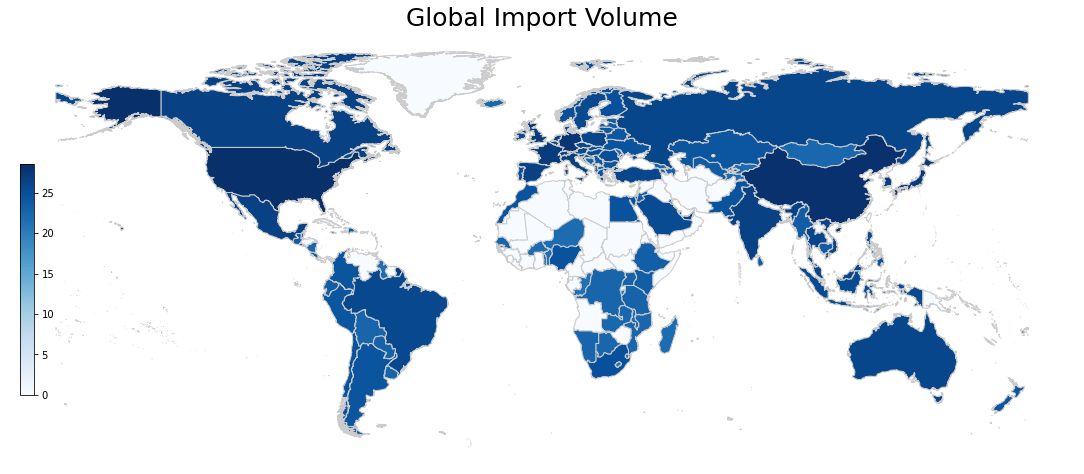

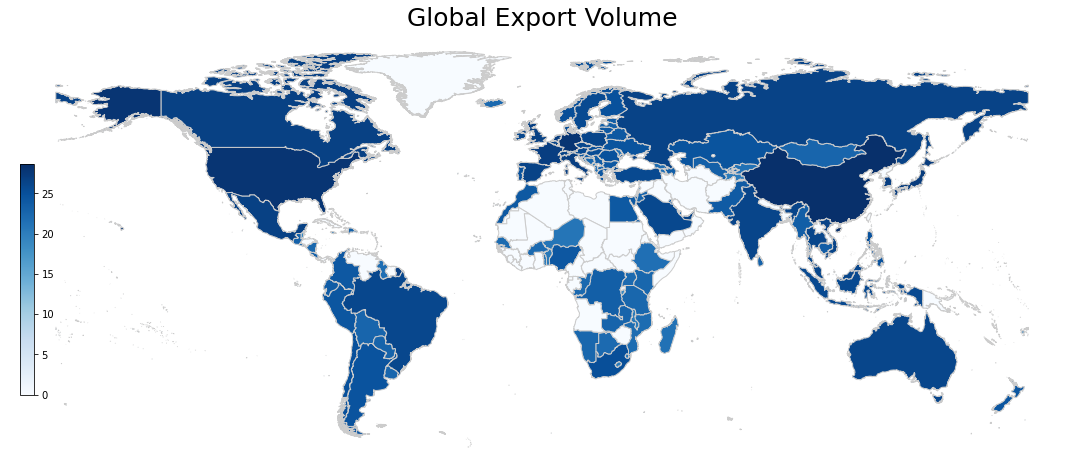

In [6]:
# Data visualization
# Print the map for import data
# Set the range for the choropleth
title = 'Global Import Volume'
col = 'log trade'
vmin = map_im[col].min()
vmax = map_im[col].max()
cmap = 'Blues'
# Create figure and axes for Matplotlib
fig, ax = plt.subplots(1, figsize=(20, 8))
# Remove the axis
ax.axis('off')
map_im.plot(column=col, ax=ax, edgecolor='0.8', linewidth=1, cmap=cmap)
# Add a title
ax.set_title(title, fontdict={'fontsize': '25', 'fontweight': '3'})
# Create colorbar as a legend
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
# Empty array for the data range
sm._A = []
# Add the colorbar to the figure
cbaxes = fig.add_axes([0.15, 0.25, 0.01, 0.4])
cbar = fig.colorbar(sm, cax=cbaxes)

# Print the map for export data
title = 'Global Export Volume'
col = 'log trade'
vmin = map_ex[col].min()
vmax = map_ex[col].max()
cmap = 'Blues'
fig, ax = plt.subplots(1, figsize=(20, 8))
ax.axis('off')
map_ex.plot(column=col, ax=ax, edgecolor='0.8', linewidth=1, cmap=cmap)
ax.set_title(title, fontdict={'fontsize': '25', 'fontweight': '3'})
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
sm._A = []
cbaxes = fig.add_axes([0.15, 0.25, 0.01, 0.4])
cbar = fig.colorbar(sm, cax=cbaxes)

### 4.1.2 Histogram of the Trading Volume of Top 10 Countries or Regions
In this subsection, we use the same dataset as the subsection above and plot the histogram to show the trading volume of top 10 countries or regions. The graph indicates that the trading volume of China is the largest(4646 billion dollar), followed by USA(3836 billion dollar) and Germany(2559 billion dollar).

##### Chart Description:
* Data source:  we use the global trade imports/exports data in section 3.1, containing trade data from 131 countries and regions.
* The bars in the plots are in decending order.


     index                countries   trade_volume
20      20                    China  4646191278389
50      50                  Germany  2559019591600
126    126  United Rep. of Tanzania  2411457967797
127    127                      USA  1437818112329
63      63                    Japan  1276684890169
21      21     China, Hong Kong SAR  1124577065534
39      39                   France  1071337751603
124    124     United Arab Emirates   969387317396
61      61                    Italy   918625062609
18      18                   Canada   792737937986


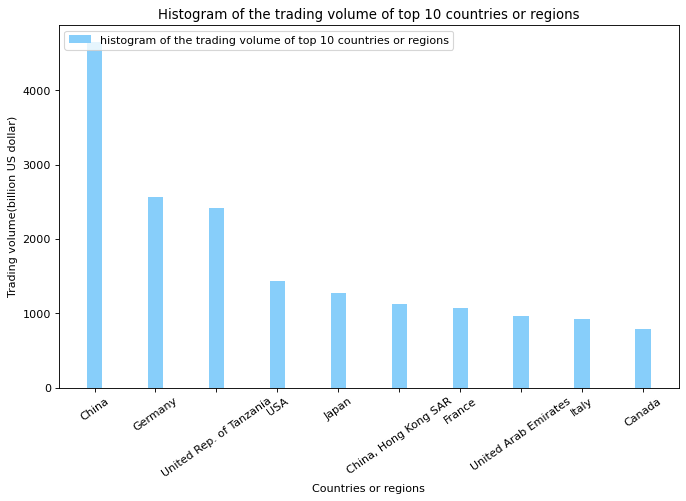

In [7]:
worldata2020 = pd.read_excel("worldata_2020.xls", index_col=0)

df_list=[]
for i in range(131):
    x = worldata2020.iloc[2*i+1, 6]+worldata2020.iloc[2*i, 6]
    df_list.append([i,worldata2020.iloc[2*i,1],worldata2020.iloc[2*i+1, 6]+worldata2020.iloc[2*i, 6]])
df_hist=pd.DataFrame(df_list)
df_hist.columns=['index','countries','trade_volume']

hist_data = df_hist.sort_values('trade_volume', ascending=False)[0:10]
print(hist_data)
country_hist = list(hist_data['countries'])

trade_hist = []
for i in country_hist:
    con_data = hist_data[hist_data['countries'] == i]
    con_index = hist_data[hist_data['countries'] == i].index
    trade_volume = con_data.at[con_index[0],'trade_volume']
    #trade_volume = import_data + export_data
    trade_hist.append(trade_volume/1000000000)

index_hist = np.arange(10)
plt.figure(figsize=(10, 6), dpi=80) 
width = 0.25
p2 = plt.bar(index_hist, trade_hist, width, label="histogram of the trading volume of top 10 countries or regions", color="#87CEFA") 
plt.xlabel('Countries or regions') 
plt.ylabel('Trading volume(billion US dollar)') 
plt.title('Histogram of the trading volume of top 10 countries or regions') 
plt.xticks(index_hist, tuple(hist_data['countries']),rotation=35)
plt.legend(loc="upper left") 
plt.show()

### 4.1.3  Balance of Trade Overview of different counrties (data in 2020)
In this section, we analyze the panel data of "Balance of Trade" in 2020. Balance of Trade is derived from the gap between total export value and total import value, which implies whether a country bears with net export or net import.

$$BalanceofTrade = TotalExports - TotalImports$$

A positive balance of trades, namely a trade surplus, means that the country exports more goods and service than that of imports. Reversely, a negative balance of trades means a trade deficit. A country that has a large trade deficit tends to unilaterally rely on foreign imports.

##### Chart Description:
* Data Source: we use the global trade imports/exports data in section 3.1, containing trade data from 131 countries and regions.
* Data Processing: we process the data with the BOT formula and use a **standardized value** instead of the orginial value to better visualize the results.
* The chart demonstrates the balance of trade of 131 countries and regions. The x-axis is the value of BOT and y-axis is the listed countries and regions. A positive BOT bar is colored as green and negative red.

##### Key Takeaways from the chart:
* Interesting findings that in term of the standardized amount, China has the largest net exports and the United States the largest net imports, according to the data in 2020. The United Kingdom is facing with the second largest net imports global-wise. More details found in the chart below.

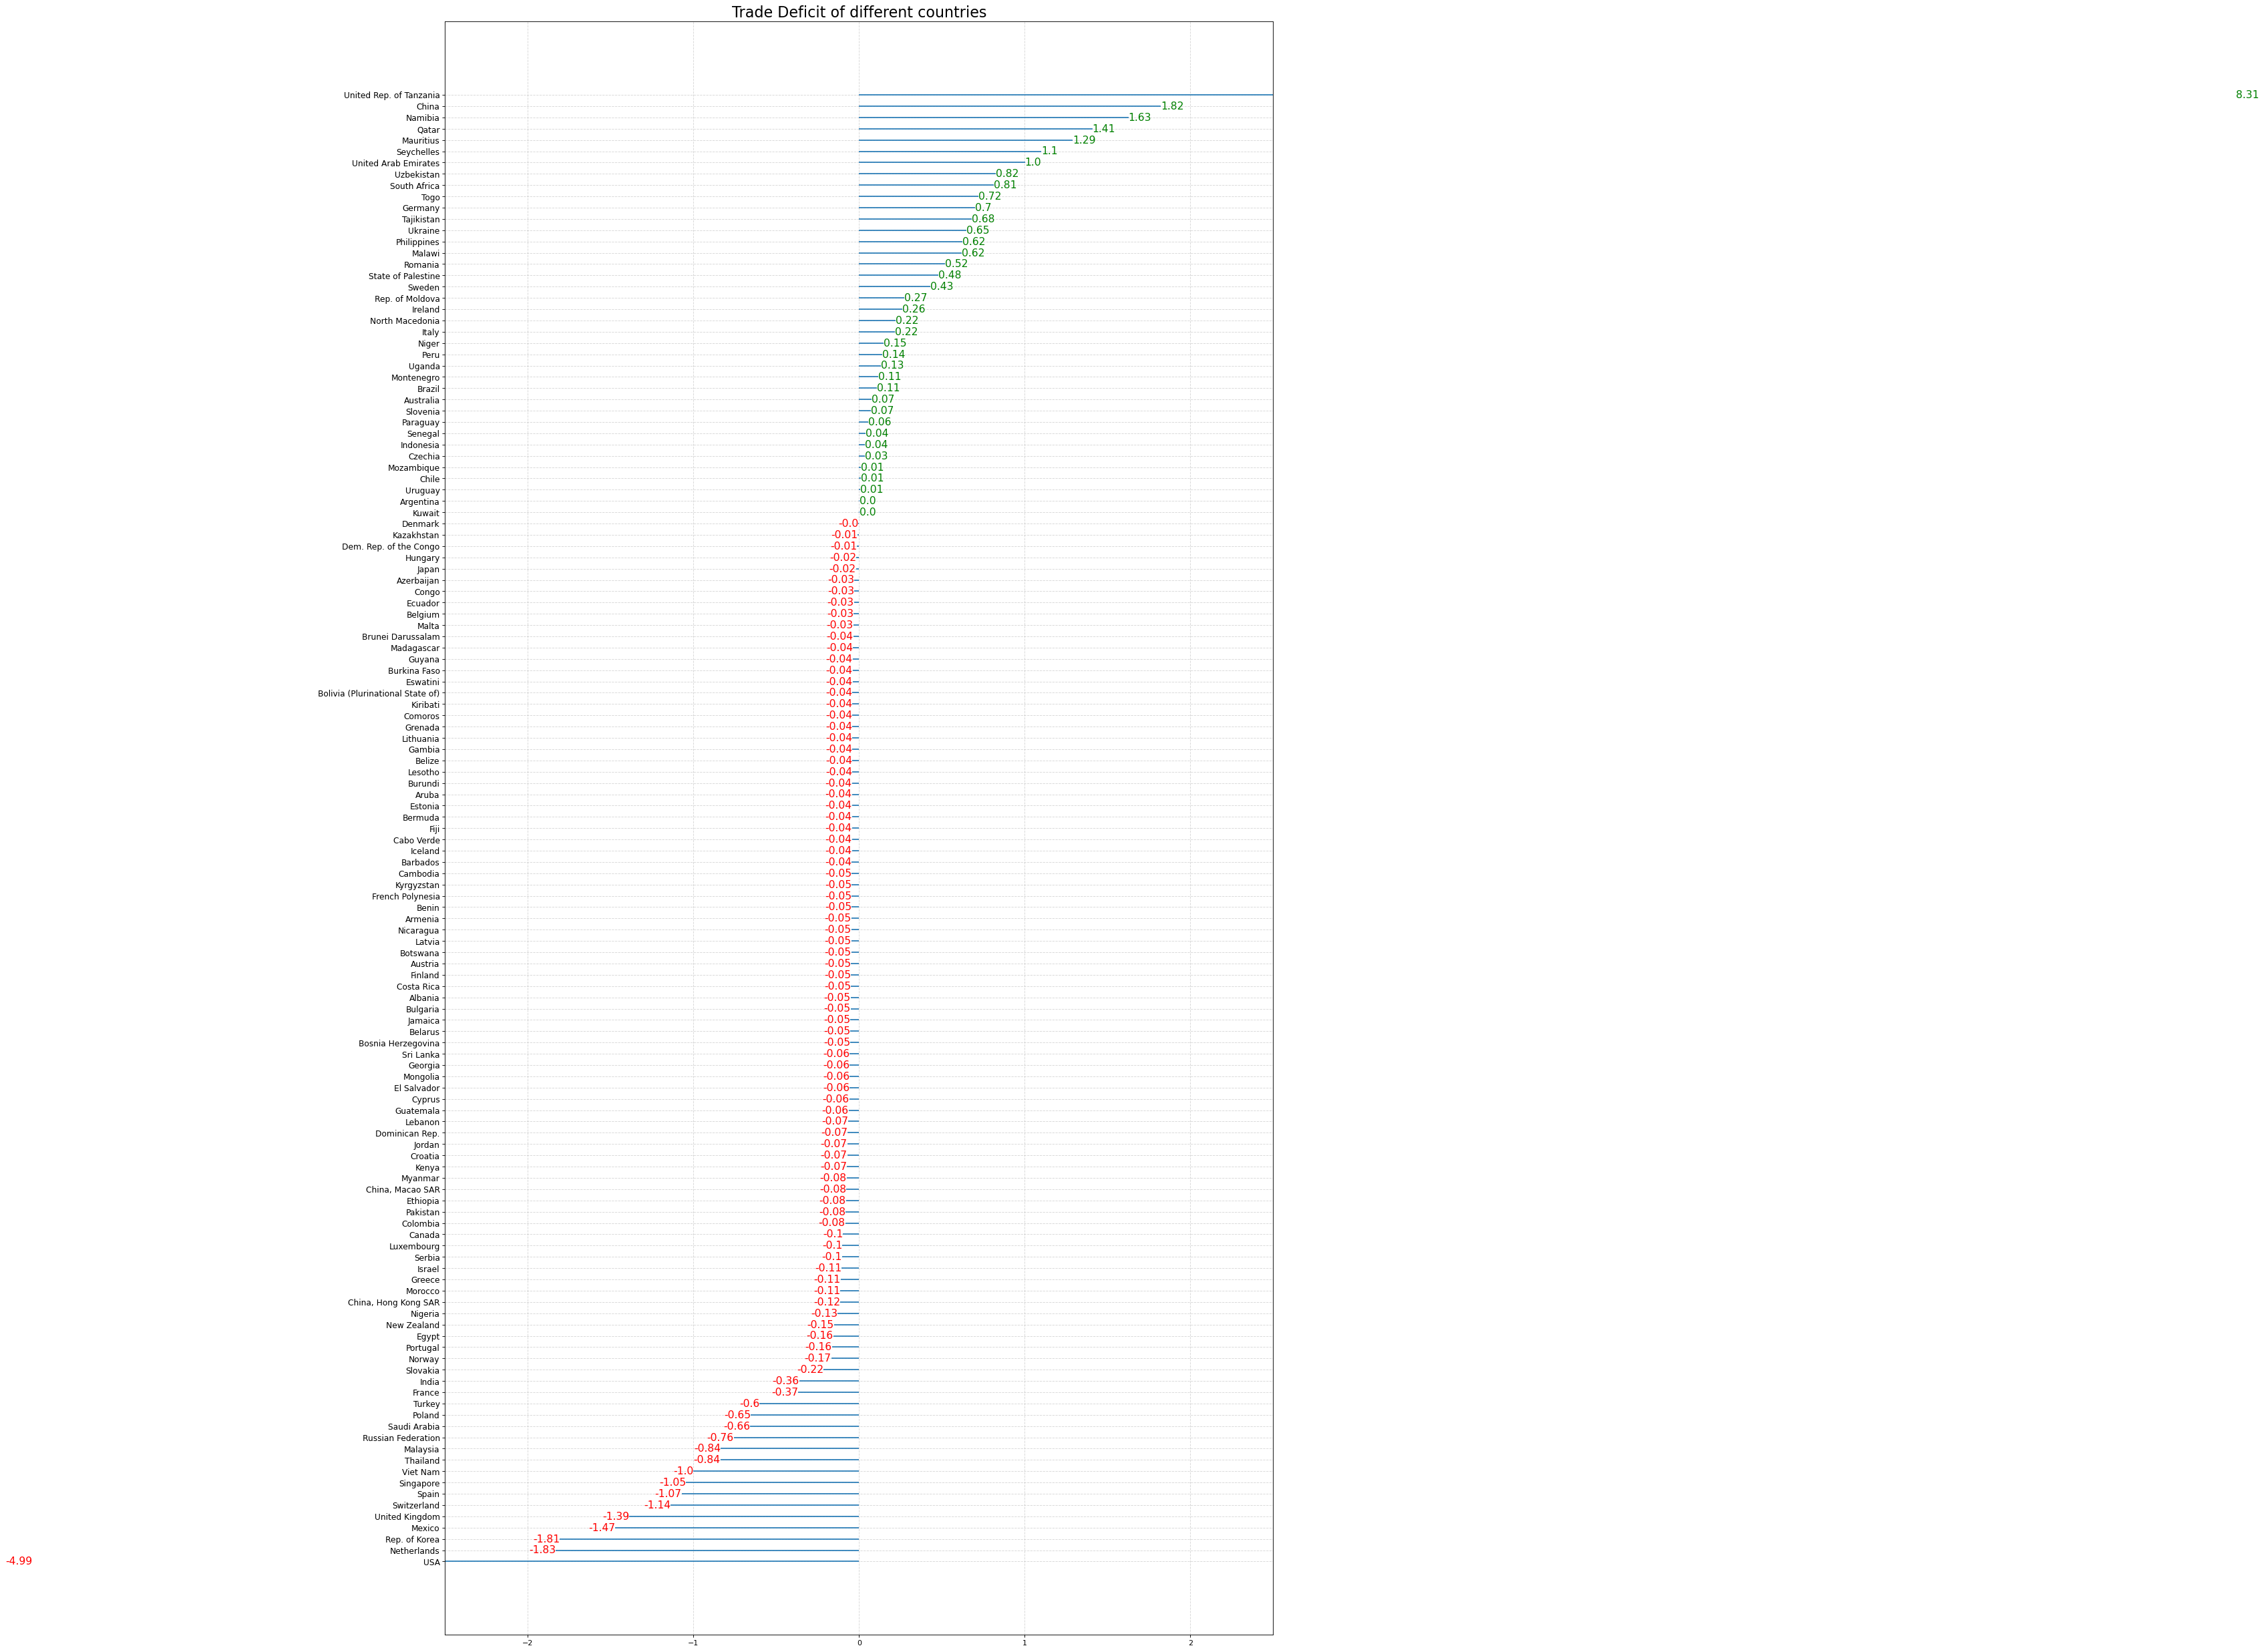

In [8]:
## Read the data
xls_file = "worldata_2020.xls"   
data = pd.read_excel(xls_file, index_col = 0)
df_list = []
for i in range(131):
    x = data.iloc[2*i+1, 6] - data.iloc[2*i, 6]
    df_list.append([i,data.iloc[2*i,1],data.iloc[2*i+1, 6] - data.iloc[2*i, 6]])
df_new = pd.DataFrame(df_list)
df_new.columns = ['index','countries','deficit']

## Prepare the data
df = df_new
x = df.loc[:, ['deficit']]
df['deficit_z'] = (x - x.mean())/x.std()
df['colors'] = ['red' if x < 0 else 'green' for x in df['deficit_z']]
df.sort_values('deficit_z', inplace=True)
df.reset_index(inplace=True)
df.index

# Draw plot
plt.figure(figsize=(20,40), dpi= 80)
plt.hlines(y=df.index, xmin=0, xmax=df.deficit_z)
for x, y, tex in zip(df.deficit_z, df.index, df.deficit_z):
    t = plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left',
                 verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':14})

# Decorations    

plt.yticks(df.index, df.countries, fontsize=11)
plt.title('Trade Deficit of different countries', fontdict={'size':20})
plt.grid(linestyle='--', alpha=0.5)
plt.xlim(-2.5, 2.5)
plt.show()

### 4.1.4 Trade Growth Rate of Different Countries in 2020 (Grouped by Continent)
In this section, we analyze the growth rate of import and export data for selected countries. The countries selected are some representative countries grouped by their continent, according to their GDP level. The growth rate is calculated as:

$$ GrowthRate =  \frac{TradeVolume2020 - TradeVolume2019}{TradeVolume2019} $$

##### Chart Description:
* Data Source: we use the global trade data acquired in section 3.2. Data generated in section 4.1.1 will also be used further. 
* Data Processing: In the first part, trading data of the selected countries in 2019 and 2020 will be converged into one dataframe. Each country will be tagged with the continent it belongs to. In the second part, A scatter plot will be presented in groups of continent, showing the growth rate of trading volume in 2020 for different countries in different continents.

##### Key Takeaways from the chart:
* The plots of import data shows a relatively similar pattern: the year 2020 saw a decline in imports for most of the countries except for China and Turkey. The figure of export data looks much more optimistic, that some developing countries have increased their exports. China, uniquely, has a positive growth rate in both import and export data in 2020.

In [9]:
# Data cleaning
# Load world trade data in 2019
worldata2019= pd.read_excel('worldata_2019.xls', index_col=0)
worldata2019_im = worldata2019[worldata2019['rg'] == 'Import']
worldata2019_ex = worldata2019[worldata2019['rg'] == 'Export']

# Merge the data of 2019 and 2020 together
data201920_im = pd.merge(left=worldata2019_im, right=worldata2020_im, how='left', left_on='Code', right_on='Code')
data201920_im = data201920_im.drop(['Year_x','Partner_x','Commodity Code_x','Year_y','Reporter_y','ISO_y','Partner_y','Commodity Code_y','rg_y','log trade'], axis=1)
data201920_ex = pd.merge(left=worldata2019_ex, right=worldata2020_ex, how='left', left_on='Code', right_on='Code')
data201920_ex = data201920_ex.drop(['Year_x','Partner_x','Commodity Code_x','Year_y','Reporter_y','ISO_y','Partner_y','Commodity Code_y','rg_y','log trade'], axis=1)

# Compute growth rate
data201920_im['growth'] = (data201920_im['Trade value_y']-data201920_im['Trade value_x'])/data201920_im['Trade value_x']
data201920_ex['growth'] = (data201920_ex['Trade value_y']-data201920_ex['Trade value_x'])/data201920_ex['Trade value_x']

# Sort the ISO code by continent
continent_Am = {'m49':[124,842,484,76,32,152,604,170,600,858],'con':'America'}
df_continent = pd.DataFrame(continent_Am)
continent_Oc = {'m49':[36,554],'con':'Oceania'}
df_continent_Oc = pd.DataFrame(continent_Oc)
df_continent = df_continent.append(df_continent_Oc, ignore_index=True)
continent_Af = {'m49':[818,710,450,231,404,834,504],'con':'Africa'}
df_continent_Af = pd.DataFrame(continent_Af)
df_continent = df_continent.append(df_continent_Af, ignore_index=True)
continent_As = {'m49':[156,360,392,410,682,764,702],'con':'Asia'}
df_continent_As = pd.DataFrame(continent_As)
df_continent = df_continent.append(df_continent_As, ignore_index=True)
continent_Eu = {'m49':[250,276,380,528,643,724,756,792,826],'con':'Europe'}
df_continent_Eu = pd.DataFrame(continent_Eu)
df_continent = df_continent.append(df_continent_Eu, ignore_index=True)
df_continent

# Merge the continent with the previous data
data201920_im = pd.merge(left=data201920_im, right=df_continent, how='left', left_on='Code', right_on='m49')
data201920_ex = pd.merge(left=data201920_ex, right=df_continent, how='left', left_on='Code', right_on='m49')

# Add tag to the data by continent
data201920_im.loc[data201920_im[data201920_im['con'].isin(['America'])].index,'tag']='0'
data201920_im.loc[data201920_im[data201920_im['con'].isin(['Oceania'])].index,'tag']='1'
data201920_im.loc[data201920_im[data201920_im['con'].isin(['Africa'])].index,'tag']='2'
data201920_im.loc[data201920_im[data201920_im['con'].isin(['Asia'])].index,'tag']='3'
data201920_im.loc[data201920_im[data201920_im['con'].isin(['Europe'])].index,'tag']='4'
data201920_ex.loc[data201920_ex[data201920_ex['con'].isin(['America'])].index,'tag']='0'
data201920_ex.loc[data201920_ex[data201920_ex['con'].isin(['Oceania'])].index,'tag']='1'
data201920_ex.loc[data201920_ex[data201920_ex['con'].isin(['Africa'])].index,'tag']='2'
data201920_ex.loc[data201920_ex[data201920_ex['con'].isin(['Asia'])].index,'tag']='3'
data201920_ex.loc[data201920_ex[data201920_ex['con'].isin(['Europe'])].index,'tag']='4'


171

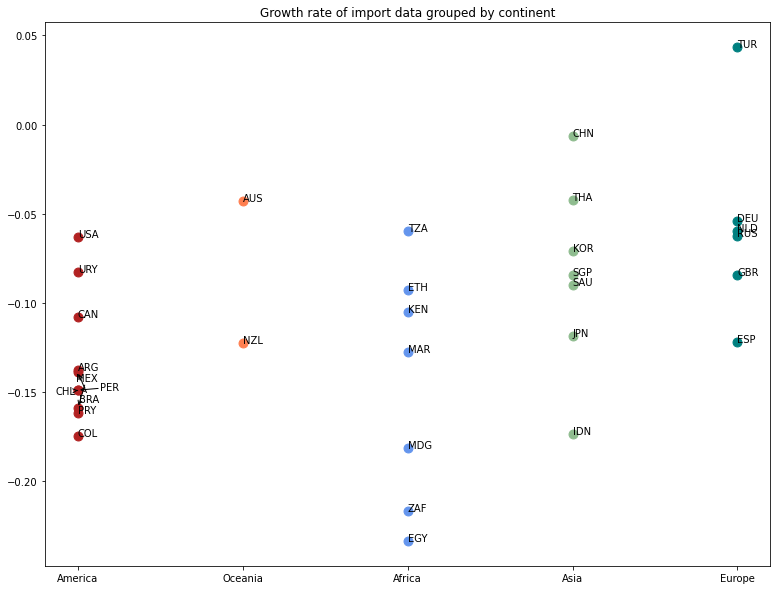

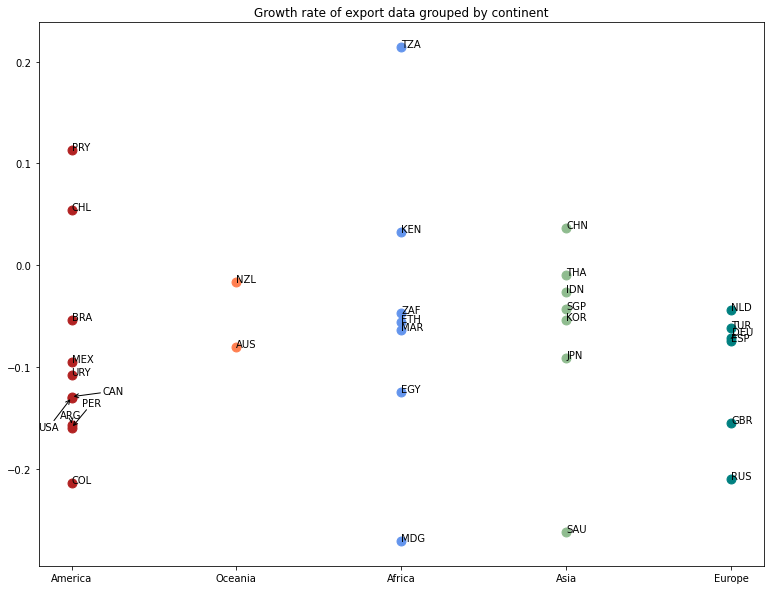

In [10]:
# Data visualization
# Draw the growth rate of different countries (group by continent)
plt.figure(figsize=(13,10))
plt.title('Growth rate of import data grouped by continent')

color = ['firebrick','coral','cornflowerblue','darkseagreen','teal']
text_total=[]
for i in range(data201920_im.shape[0]):
    plt.scatter(data201920_im['con'][i],data201920_im['growth'][i],c=color[int(data201920_im['tag'][i])],s=80)  # Draw the scatter plot in groups of continent
    if (data201920_im['ISO_x'][i] in ['MEX','PER','CHL','BRA']):  # Pick out the countries whose names overlap with each other
        text_total.append(plt.text(data201920_im['con'][i],data201920_im['growth'][i],data201920_im['ISO_x'][i]))
    else:
        plt.text(data201920_im['con'][i],data201920_im['growth'][i],data201920_im['ISO_x'][i])
adjust_text(text_total,autoalign='xy',arrowprops=dict(arrowstyle="->", color='black', lw=1))  # Adjust the position of the overlapped names


plt.figure(figsize=(13,10))
plt.title('Growth rate of export data grouped by continent')

color = ['firebrick','coral','cornflowerblue','darkseagreen','teal']
text_total=[]
for i in range(data201920_ex.shape[0]):
    plt.scatter(data201920_ex['con'][i],data201920_ex['growth'][i],c=color[int(data201920_ex['tag'][i])],s=80)
    if (data201920_ex['ISO_x'][i] in ["CAN","USA",'ARG','PER','DEU']):
        text_total.append(plt.text(data201920_ex['con'][i],data201920_ex['growth'][i],data201920_ex['ISO_x'][i]))
    else:
        plt.text(data201920_ex['con'][i],data201920_ex['growth'][i],data201920_ex['ISO_x'][i])
adjust_text(text_total,only_move={'texts':'xy'},arrowprops=dict(arrowstyle="->", color='black', lw=1))



## 4.2 The trade correlation among G-20 countries
In this subsection, the trade correlations among G-20 countries are of main interest. Two elaborate plots, the co-cluster structure and the trading network among them, are generated in turn. 


### 4.2.1 Co-cluster structure of G-20 countries

Text(0.5, 1.0, 'in order of the Fiedler vector elements')

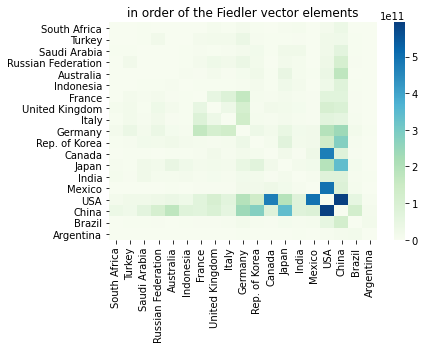

In [11]:
data_co = pd.read_excel('interdata_2020.xls', index_col=0)
data_co = data_co.fillna(0)

names1 = data_co.index
names2 = data_co.columns

row = data_co.shape[0]
col = data_co.shape[1]
list1 = [[0 for i in range(row)] for i in range(col)]

for i in range(row):
    for j in range(col):
        list1[i][j] = data_co[names1[i]][j] + data_co[names1[j]][i]
data1 = pd.DataFrame(list1)
data1.index = names1
data1.columns = names2

list2 = np.array(list1)
list_perm = list2  

# compute the Laplacian matrix
L = np.diag(np.sum(list_perm,1)) - list_perm

# compute eigenvalues and eigenvectors of the Laplacian matrix
D, V = np.linalg.eigh(L)
argD = np.argsort(D)
D=D[argD]
V=V[:,argD]

# get the Fiedler eigenvector
fiedler = V[:,1]
Fperm = np.argsort(fiedler)
list_perm2 = list_perm[Fperm,:]
list_perm2 = list_perm2[:,Fperm]

languages = []
for i in range(19):
    languages.append(names1[i])


# Rearrange the language list

languages1 = []

for i in range(19):
    languages1.append(languages[Fperm[i]])
# convert into dataframe
Aperm2_dataframe = pd.DataFrame(list_perm2,columns=languages1,index=languages1)

fig, ax = plt.subplots()
seaborn.heatmap(data=Aperm2_dataframe,cmap="GnBu")

plt.title("in order of the Fiedler vector elements")

In this subsection, we focus on the trading partner relationships among G-20 countries. In this graph, these nodes stand for the 19 countries respectively, and the width of the edge represents the mutual trading volume. After plotting the network graph, we calculate the eigenvector centrality to model the position of each country in the trade network.

##### Data Source:
* Mutual Trade Volume: we use the dataset from UN Comtrade dataset in Section 3.3.

##### Key Takeaways:
* USA and China are in the core positions in this network. From the graph, we can see that the edges combined with USA and China are relatively wider than others. The analysis of the eigenvector centrality can further prove this view, because the eigenvector centralities of China and USA are significantly higher than other countries.
* From the graph, it can be found that USA have high trade flows with Canada and Mexico, while China has close trade partnership with Japan and Korea. So we can conclude that the trading volume is generally negatively correlated to the geographical distance.

In [12]:
# Data cleaning
table = xlrd.open_workbook('interdata_2020.xls').sheets()[0]
row = table.nrows
col = table.ncols
datamatrix = []
for x in range(col):
    datamatrix.append(table.col_values(x))

country_name = datamatrix[0][1:]
data_set = [i[1:] for i in datamatrix[1:]]

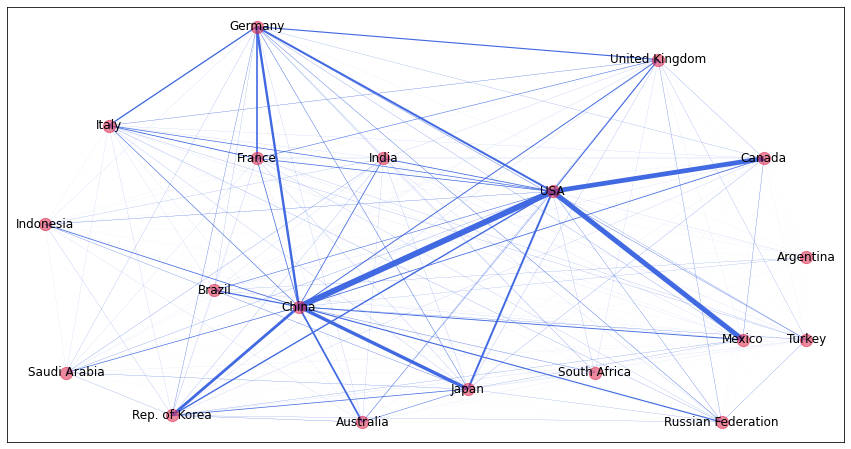

In [13]:
G = nx.Graph()
coordinates=[[19,6],[8.5,1],[5,5],[18,9],[7,4.5],[6,9],[6,13],[9,9],[1,7],[2.5,10],[11,2],[17.5,3.5],[4,1.2],[17,1],[1.5,2.5],[14,2.5],[19,3.5],[15.5,12],[13,8]]
location = np.array(coordinates)
npos = dict(zip(country_name, location))
for m in country_name:
    G.add_node(m)
for i in range(len(data_set)):
    for j in range(len(data_set)):
        if i != j:
            G.add_edge(country_name[i], country_name[j], color='royalblue', weight = (data_set[i][j] + data_set[j][i])/100000000000)

pos=nx.spring_layout(G)
pos.update(npos)
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]
weights = [G[u][v]['weight'] for u,v in edges]
plt.figure(figsize=(15,8)) 
nx.draw_networkx_nodes(G, pos, node_color='crimson',node_size=150,alpha=0.5)
nx.draw_networkx_edges(G, pos, edge_color=colors, width=weights)
nx.draw_networkx_labels(G, pos,font_size=12)

plt.show()

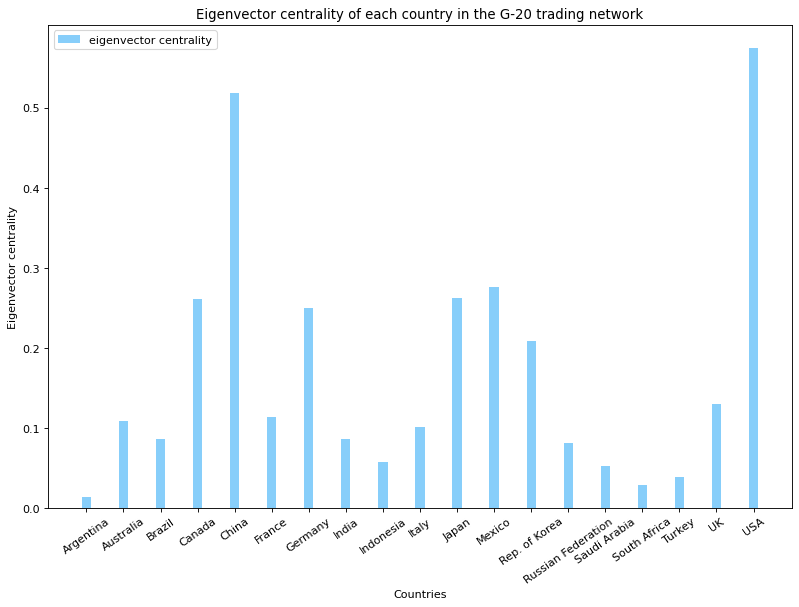

In [15]:
eigenvector_cen = nx.eigenvector_centrality(G, max_iter=1000000000000000000, weight='weight')
# print('eigenvector centrality:',eigenvector_cen)
eigen_data = []

for key in list(eigenvector_cen.keys()):
    eigen_data.append(eigenvector_cen[key])
index = np.arange(19)
plt.figure(figsize=(12, 8), dpi=80) 
width = 0.25
p2 = plt.bar(index, eigen_data, width, label="eigenvector centrality", color="#87CEFA") 
plt.xlabel('Countries') 
plt.ylabel('Eigenvector centrality') 
plt.title('Eigenvector centrality of each country in the G-20 trading network') 
plt.xticks(index, ('Argentina','Australia','Brazil','Canada','China','France','Germany','India','Indonesia','Italy','Japan','Mexico','Rep. of Korea',
                       'Russian Federation','Saudi Arabia','South Africa','Turkey','UK','USA'),rotation=35)
plt.yticks(np.arange(0, 0.6, 0.1)) 
plt.legend(loc="upper left") 
plt.show()

## 4.3 China's role in international trade
In this subsection, we will cover several aspects to study the role China is playing in the international trading system. In the first place, a time series plot for the balance of China will be generated. In the second place, more detailed division will be conducted, and the composition of goods and services imported and exported by China will appear in the form of tree maps. In the third place, a Sankey diagram will summarise the buyers of the cargos exported by China. And finally, the gravity model, a well-celebrated model in international trade theory, will be introduced and applied to visualization. 

### 4.3.1 Time Series of China's Balance of Trade from 1993~2020
Here we shows a time series chart demonstrating China's balance of trade account from 1993~2020. We use the data from Section 3.2.
##### Key takeaways:
See in the chart below, the small red part around 1993 implies to a temporary trade deficit during that period and then China entered an all-green era, which stands for a long-term trade surplus pattern. China has long acted as a global manufacturer and kept fast-developing manufacturing technique, which ensures its strong exports capability.

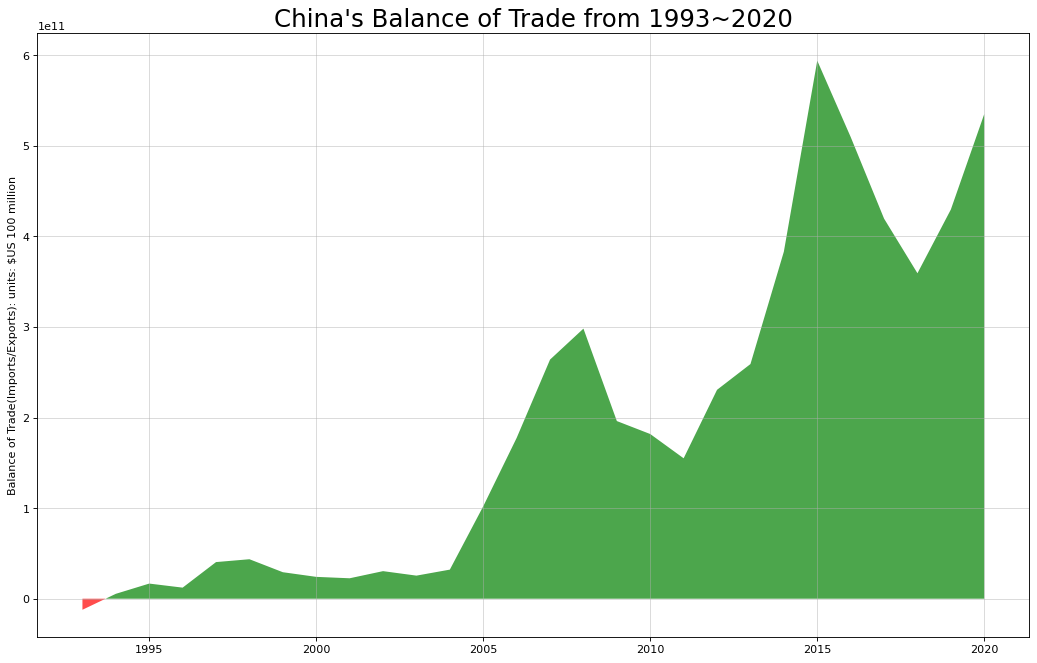

In [16]:
df_CH = pd.read_excel("deficit.xls", index_col=0)
df_list=[]
for i in range(28):
    x = df_CH.iloc[2*i+1, 6] - df_CH.iloc[2*i, 6]
    df_list.append([df_CH.iloc[2*i,0], x])
df_new = pd.DataFrame(df_list)

# Plot
plt.figure(figsize=(16,10), dpi= 80)
plt.fill_between(df_new[0:][0], df_new[0:][1], 0, where= df_new[0:][1] >= 0, facecolor='green', interpolate=True, alpha=0.7)
plt.fill_between(df_new[0:][0], df_new[0:][1], 0, where= df_new[0:][1] <= 0, facecolor='red', interpolate=True, alpha=0.7)
# Annotate
plt.title("China's Balance of Trade from 1993~2020", fontsize=22)
plt.ylabel('Balance of Trade(Imports/Exports): units: $US 100 million')
plt.grid(alpha=0.5)

### 4.3.2 Tree maps of goods and services imported and exported by China
In this subsection, we focus on China's trade data more detailed, as we divided all goods and services into 10 categories. Two tree maps are generated to give an overview of the proportion of each category in import and export trade data in 2020, respectively.

##### Chart Description:
* Data Source: data from section 3.5 will be used to explore the composition of China's import and export trade value.
* Data Processing: we first rank the 10 categories by trade volume, and generate the tree maps with the size of each category represent the value of the traded goods and services.

##### Key Takeaways from the chart:
* Among all goods and services imported and exported by China in 2020, machinery and transport equipments take the biggest part. If we specifically look at the import data, crude materials come the second, with mineral fuels, lubricants and related materials coming the third, which are both raw materials needed for processing and production. As for export data, miscellaneous manufactured articles and Manufactured goods rank after machinery and transport equipments. This two patterns clearly illustrate China's role in the international trading system.

In [17]:
# Data cleaning
China2020 = pd.read_excel("China_2020.xls")
China2020_im = China2020[China2020['rg'] == 'Import']
China2020_ex = China2020[China2020['rg'] == 'Export']
China2020_im['shortnames'] = ['Food & live animals','Beverages & tobacco','Crude materials','Mineral fuels','Oils','Chemicals','Manufactured goods','Machinery and transport equipment','Miscellaneous articles','Commodities']
China2020_ex['shortnames'] = ['Food & live animals','Beverages & tobacco','Crude materials','Mineral fuels','Oils','Chemicals','Manufactured goods','Machinery and transport equipment','Miscellaneous articles','Commodities']
China2020_im = China2020_im.sort_values("Value", ascending=False)
China2020_ex = China2020_ex.sort_values("Value", ascending=False)

<ipython-input-17-da9c5968f478>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  China2020_im['shortnames'] = ['Food & live animals','Beverages & tobacco','Crude materials','Mineral fuels','Oils','Chemicals','Manufactured goods','Machinery and transport equipment','Miscellaneous articles','Commodities']
<ipython-input-17-da9c5968f478>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  China2020_ex['shortnames'] = ['Food & live animals','Beverages & tobacco','Crude materials','Mineral fuels','Oils','Chemicals'

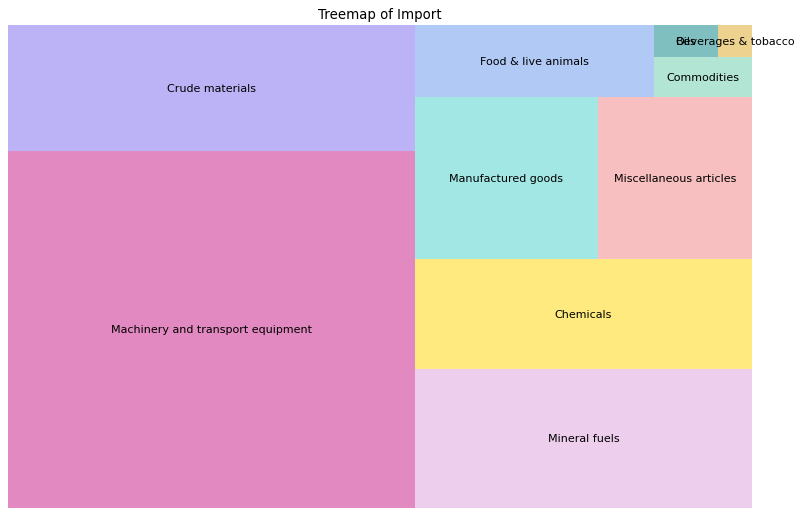

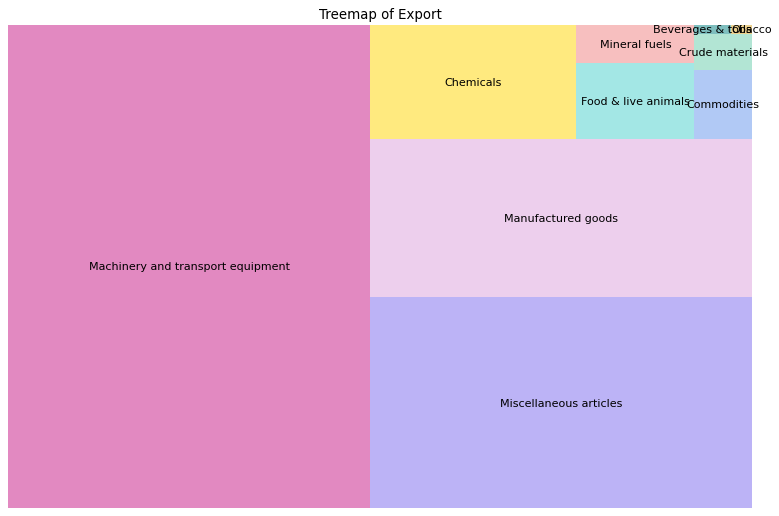

In [18]:
# Prepare for plotting
labels_im = China2020_im['shortnames']
sizes_im = China2020_im['Value'].values.tolist()
labels_ex = China2020_ex['shortnames']
sizes_ex = China2020_ex['Value'].values.tolist()
colors=['mediumvioletred','mediumslateblue','plum','gold','mediumturquoise','lightcoral','cornflowerblue','mediumaquamarine','teal','goldenrod']

# Draw Plot
plt.figure(figsize=(12,8), dpi= 80)
squarify.plot(sizes=sizes_im, label=labels_im, alpha=.5,color=colors)
plt.title('Treemap of Import')
plt.axis('off')
plt.show()

plt.figure(figsize=(12,8), dpi= 80)
squarify.plot(sizes=sizes_ex, label=labels_ex, alpha=.5,color=colors)
plt.title('Treemap of Export')
plt.axis('off')
plt.show()


### 4.3.3 Sankey Diagram of China's Export in 2020
In this subsection, we plot the sankey diagram of China's export to five main trading partners, which are USA, Germany, Japan, UK and Korea. Sankey diagrams feature directed arrows that have a width proportional to the flow quantity visualized, drawing the attention to the largest and most significant entries within a system.

##### Chart Description:
* Data Source: we use the categorized export data of China to 5 selected countries generated in section 3.6.
* The flow of the diagram is from left to right, indicating the export of goods and services from China to the other five countries. The width of the flow is proportional to the trade volume of the specific category, showing not only values but also information about the structure and distribution of the export data of China.

##### Key Takeaways from the chart:
* All the five countries show quite similar structure for the goods and services imported from China. 
* It comes with no surprise that the USA is the largest export partner of China. The USA imports mostly the machinery and transport equipments, miscellaneous manufactured articles and Manufactured goods, which are the top three categories China exports according to plots in section 4.3.2. Japan acquires in the second place, and Korea takes the third place, possibly on account of their distance to China, as well as their outperformance in GDP, relative to other Asian countries.

In [19]:
nodes = []
for i in range(2):
    names = df_sankey.iloc[:,i].unique()
    for name in names:
        dic = {}
        dic['name'] = name
        nodes.append(dic)

linkes = []
for i in df_sankey.values:
    dic={}
    dic['source']=i[0]
    dic['target']=i[1]
    dic['value']=i[2]
    linkes.append(dic)
    
pic = (
    Sankey()
    .add('', 
         nodes,    
         linkes,   
         linestyle_opt=opts.LineStyleOpts(opacity = 0.3, curve = 0.5, color = "source"),
         label_opts=opts.LabelOpts(position="right"),
         node_gap = 30,
    )
    .set_global_opts(title_opts=opts.TitleOpts(title = 'The export of China'))
)
pic.render('The export of china.html')

'/Users/emerald/Documents/GitHub/445/FinalProject/The export of china.html'

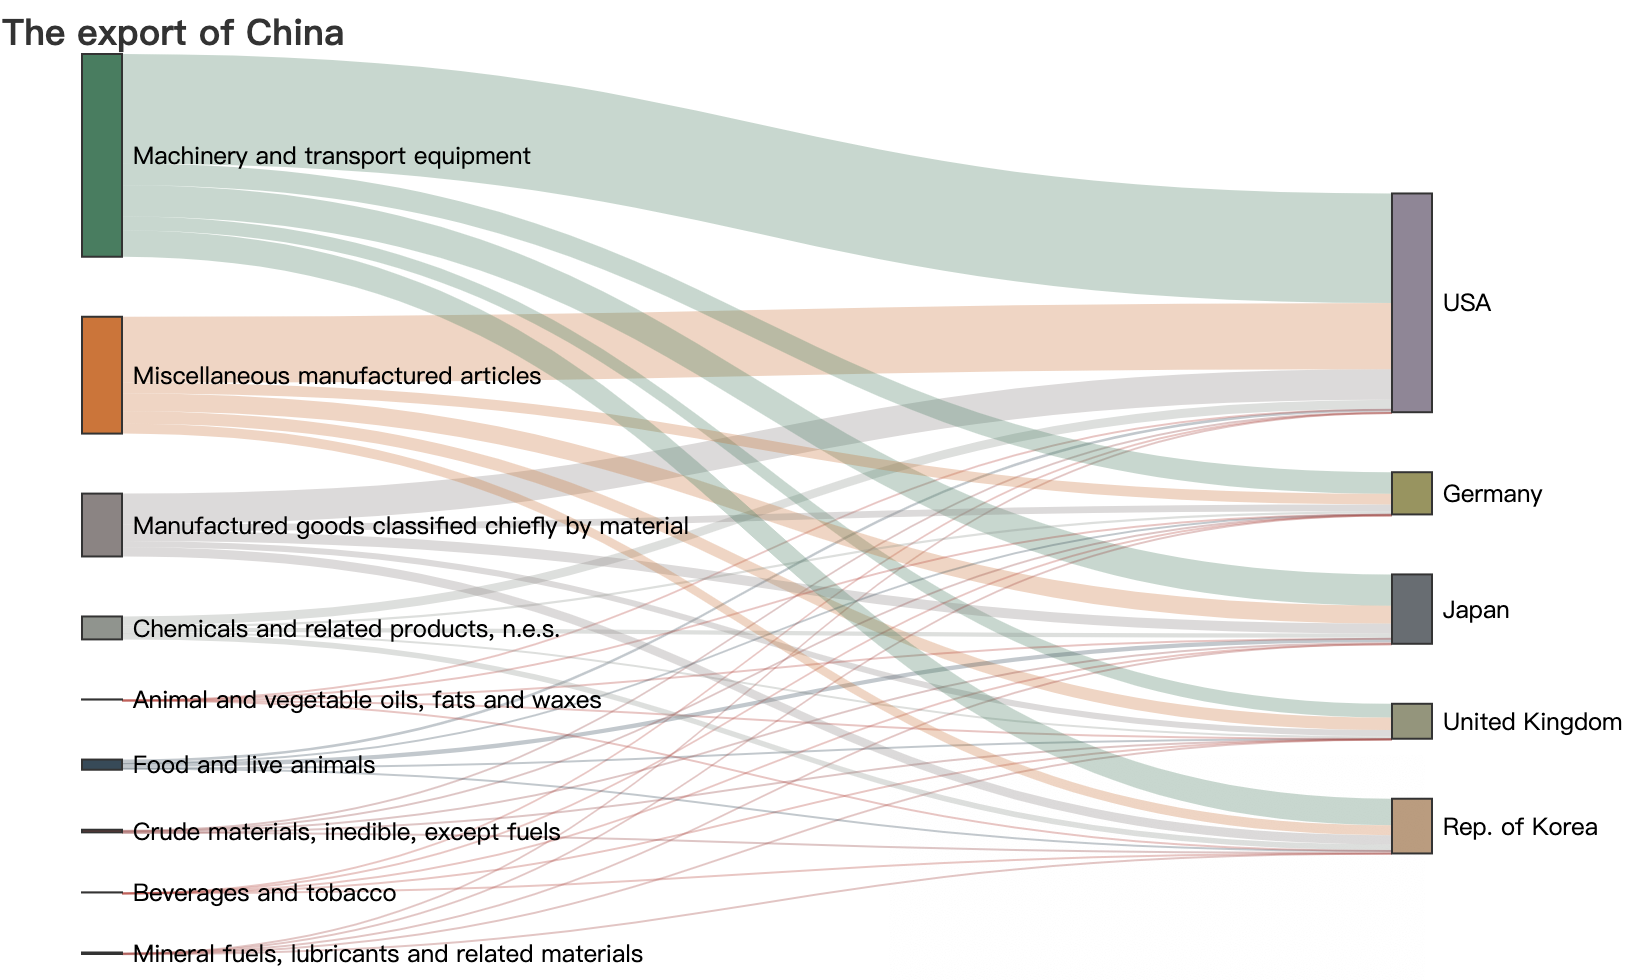

### 4.3.4 Bubble Chart: Empirical Analysis of Gravity model of Trade in China (Date as for 2020)
In this subsection, we conduct an empirical analysis on the gravity model of trade. The gravity model is long used to predict bilateral trade flows of two countries/regions, based on their GDP sizes and geographical distances. The larger the two countries' GDPs sizes and the closer the countries, the more trade volume is expected. The basic formula is shown below:

$$F_ij= G * \frac{M_iM_j}{Distance}$$

##### Data Source:
* Mutual Trade Volume: we use the dataset from UN Comtrade dataset in Section 3.3.
* GDP data: use web scrapping on the website to get the GDP data from 
https://tradingeconomics.com/country-list/gdp
* Geographical Distances from China: as for the countries studied, we use the distances between each capital and Beijing to illustrate the distances between each countries and China. We use web srapping to get all the capitals name and their longtitude and latitude data from http://techslides.com/list-of-countries-and-capitals#google_vignette. Then use spherical distance formula to get the distance.

##### Key Takeaways:
* The trading pattern of China in 2020 can not be precisely applied to the gravity model. United States is China's largest trade partner despite the considerable distance.
* We can roughly see the trend of larger trade volume with small distance and high GDPs from the East Asia trading partner of China.  
* The ineffectiveness of gravity model may result from other economic factors apart from distances and GDPs, like the industry structures and transportation convenience.

In [20]:
### Calculate the distance between China and other G20 counrties 
### Here we use the distance between each two of the capital cities to illustrate the distance.
# Get the name of all cities in UK
page = requests.get("http://techslides.com/list-of-countries-and-capitals#google_vignette")
soup = BeautifulSoup(page.content,'lxml')
trs = soup.find_all("tr")

# Calculat the distance
import math
def distance(longitude,latitude):
    longi = longitude*math.pi/180
    latit = latitude*math.pi/180
    beijing_longi = 116.3*math.pi/180
    beijing_latit = 39.9*math.pi/180
    distance=6370*math.acos(math.sin(beijing_latit)*math.sin(latit)+math.cos(beijing_latit)*math.cos(latit)*math.cos(beijing_longi-longi))
    return distance


cities = []
for tr in trs:
    tds = tr.find_all('td')
    ccode = []
    if len(str(tds[4]).replace("<td>","").replace("</td>","")) >= 3:
        continue
    ccode.append(str(tds[4]).replace("<td>","").replace("</td>",""))
    ccode.append(str(tds[2]).replace("<td>","").replace("</td>",""))
    ccode.append(str(tds[3]).replace("<td>","").replace("</td>",""))
    ccode.append(str(tds[0]).replace("<td>","").replace("</td>","").replace(" ",""))
    cities.append(ccode)

cities

city_distance = []
for i in range(len(cities)):
    bj_dist = []
    bj_dist.append(cities[i][0])
    bj_dist.append(cities[i][3])
    bj_dist.append(distance(float(cities[i][2]),float(cities[i][1])))
    city_distance.append(bj_dist)

# city_distance

In [21]:
# Get the G20 list and GDPs
page = requests.get("https://tradingeconomics.com/country-list/gdp")
soup = BeautifulSoup(page.content,'lxml')
G20Sum = []
G20name = []
trs = soup.find_all("tr")
# Scripe
for tr in trs:
    tds = tr.find_all('td')
    if len(tds) <= 2:  # The first tr is [], avoid the error
        continue
    GC = tds[0].text.split('(')[0].strip('0123456789,\n')
    GC = str(GC).replace("\r\n","").replace(" ","")
    GGdp = int(tds[1].text.split('>')[0].strip('\n'))
    #GGdp = str(GC).replace("\r\n","").replace(" ","")
    G20name.append([GC,GGdp])
    
G20name_s = []
for i in range(len(G20name)):
    if G20name[i][0] == 'China':
        continue
    if G20name[i][0] == 'EuroArea':
        continue
    G20name_s.append(G20name[i])

# Gather all the data
for i in range(243):
    for j in range(len(G20name_s)):
        if G20name_s[j][0] == city_distance[i][1]:
            G20name_s[j].append(city_distance[i][2])

### Import the data of mutual trade  
volumeraw = pd.read_excel("interdata_2020.xls", index_col=0)
volumeraw = pd.DataFrame(volumeraw)
volume = volumeraw.rename(index={'Rep. of Korea': 'SouthKorea', 'Russian Federation': 'Russia',
                                 'Saudi Arabia': 'SaudiArabia', 'South Africa': 'SouthAfrica',
                                 'United Kingdom': 'UnitedKingdom', 'USA': 'UnitedStates',
                                 })
for i in range(len(G20name_s)):
    for j in range(19):
        if G20name_s[i][0] == volume.index[j]:
            G20name_s[i].append(volume.iloc[j, 4])
G20name_ss = []
for i in range(len(G20name_s)):
    if len(G20name_s[i]) == 4:
        G20name_ss.append(G20name_s[i])

In [22]:
### Plot and annotate
names = []
for i in range(len(G20name_ss)):
    names.append(G20name_ss[i][0])
gdps = []
for i in range(len(G20name_ss)):
    gdps.append(G20name_ss[i][1])
distances = []
for i in range(len(G20name_ss)):
    distances.append(G20name_ss[i][2])
sizes = [] 
for i in range(len(G20name_ss)):
    sizes.append(G20name_ss[i][3])
color = np.random.rand(len(G20name_ss))


colors = np.random.rand(len(G20name_ss))
data_for_plot=pd.DataFrame(np.array([[distances],[gdps],[sizes]]).transpose()[:,0,:])
data_for_plot.columns=["Geographical Distance from China","GDP in 2020","Mutual Trade Volume with China"]
fig = px.scatter(data_for_plot,x ="Geographical Distance from China", y="GDP in 2020",
                 size="Mutual Trade Volume with China", color=color,
                 hover_name=names, log_x=True, size_max=100,
                 title = 'Empirical Analysis of Gravity model in China (Date as for 2020)')
# plt.title('Bubble Chart_Country GDP and distances with trade volume')\
fig.update(layout_coloraxis_showscale = False)
fig.show()

# 5 Conclusion
1. China and the USA are the two most active players in global trade. They are the world largest trade surplus country and deficit country, respectively, and we can see strong trading partnership between them.
2. China has long been an exporter in the past two decades, mainly exporting industrial products including machinery and transport equipments, miscellaneous manufactured articles and Manufactured goods.